In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, Input, Model 
from tensorflow.keras.layers import LSTM, Dense, Concatenate, TimeDistributed


In [2]:
# Load datasets
fred_md = pd.read_csv("FRED_MD.csv", index_col=0, parse_dates=True, date_format="%m/%d/%Y")
fred_qd = pd.read_csv("FRED_QD.csv", index_col=0, parse_dates=True, date_format="%m/%d/%Y")

# Drop metadata rows (first row for MD, first two for QD)
fred_md = fred_md.iloc[1:].apply(pd.to_numeric, errors='coerce')
fred_qd = fred_qd.iloc[2:].apply(pd.to_numeric, errors='coerce')

# Convert index to datetime (if not already)
fred_md.index = pd.to_datetime(fred_md.index)
fred_qd.index = pd.to_datetime(fred_qd.index)

In [3]:
# --- STEP 5: Define selected features ---
monthly_features = [
    # "VIXCLSx", "GS10", "TB3MS", "CPIAUCSL", "INDPRO", "M2SL",
    # "UNRATE", "PAYEMS", "HOUST", "RETAILx", "BUSINVx", "FEDFUNDS", "M1SL", "PERMIT"
    
    "VIXCLSx", "GS10", "TB3MS", "CPIAUCSL", "INDPRO",
    "UNRATE", "PAYEMS", "HOUST", "RETAILx", "BUSINVx", "FEDFUNDS", "PERMIT"
]
quarterly_features = ["GDPC1"]

# --- STEP 6: Subset features ---
monthly_selected = fred_md[monthly_features]
quarterly_selected = fred_qd[quarterly_features]

# --- STEP 7: Trim between 1962-07-01 and 2024-12-31 ---
start_date = pd.Timestamp("1962-07-01")
end_date = pd.Timestamp("2019-12-28")

monthly_trimmed = monthly_selected.loc[(monthly_selected.index >= start_date) & (monthly_selected.index <= end_date)]
quarterly_trimmed = quarterly_selected.loc[(quarterly_selected.index >= start_date) & (quarterly_selected.index <= end_date)]

# --- Final check ---
print("Date Range:", start_date.date(), "to", end_date.date())
print("Monthly shape:", monthly_trimmed.shape)
print("Quarterly shape:", quarterly_trimmed.shape)
print("Monthly missing values (null):\n", monthly_trimmed.isnull().sum())
print("Quarterly missing values (null):\n", quarterly_trimmed.isnull().sum())

print("Monthly missing values (na):\n", monthly_trimmed.isna().sum())
print("Quarterly missing values (na):\n", quarterly_trimmed.isna().sum())


Date Range: 1962-07-01 to 2019-12-28
Monthly shape: (690, 12)
Quarterly shape: (230, 1)
Monthly missing values (null):
 VIXCLSx     0
GS10        0
TB3MS       0
CPIAUCSL    0
INDPRO      0
UNRATE      0
PAYEMS      0
HOUST       0
RETAILx     0
BUSINVx     0
FEDFUNDS    0
PERMIT      0
dtype: int64
Quarterly missing values (null):
 GDPC1    0
dtype: int64
Monthly missing values (na):
 VIXCLSx     0
GS10        0
TB3MS       0
CPIAUCSL    0
INDPRO      0
UNRATE      0
PAYEMS      0
HOUST       0
RETAILx     0
BUSINVx     0
FEDFUNDS    0
PERMIT      0
dtype: int64
Quarterly missing values (na):
 GDPC1    0
dtype: int64


In [4]:
monthly_missing_trimmed = monthly_trimmed.isna().sum().sort_values(ascending=False)
quarterly_missing_trimmed = quarterly_trimmed.isna().sum().sort_values(ascending=False)

# Filter to only show features with any missing values
monthly_missing_trimmed = monthly_missing_trimmed[monthly_missing_trimmed > 0]
quarterly_missing_trimmed = quarterly_missing_trimmed[quarterly_missing_trimmed > 0]

monthly_missing_trimmed, quarterly_missing_trimmed


(Series([], dtype: int64), Series([], dtype: int64))

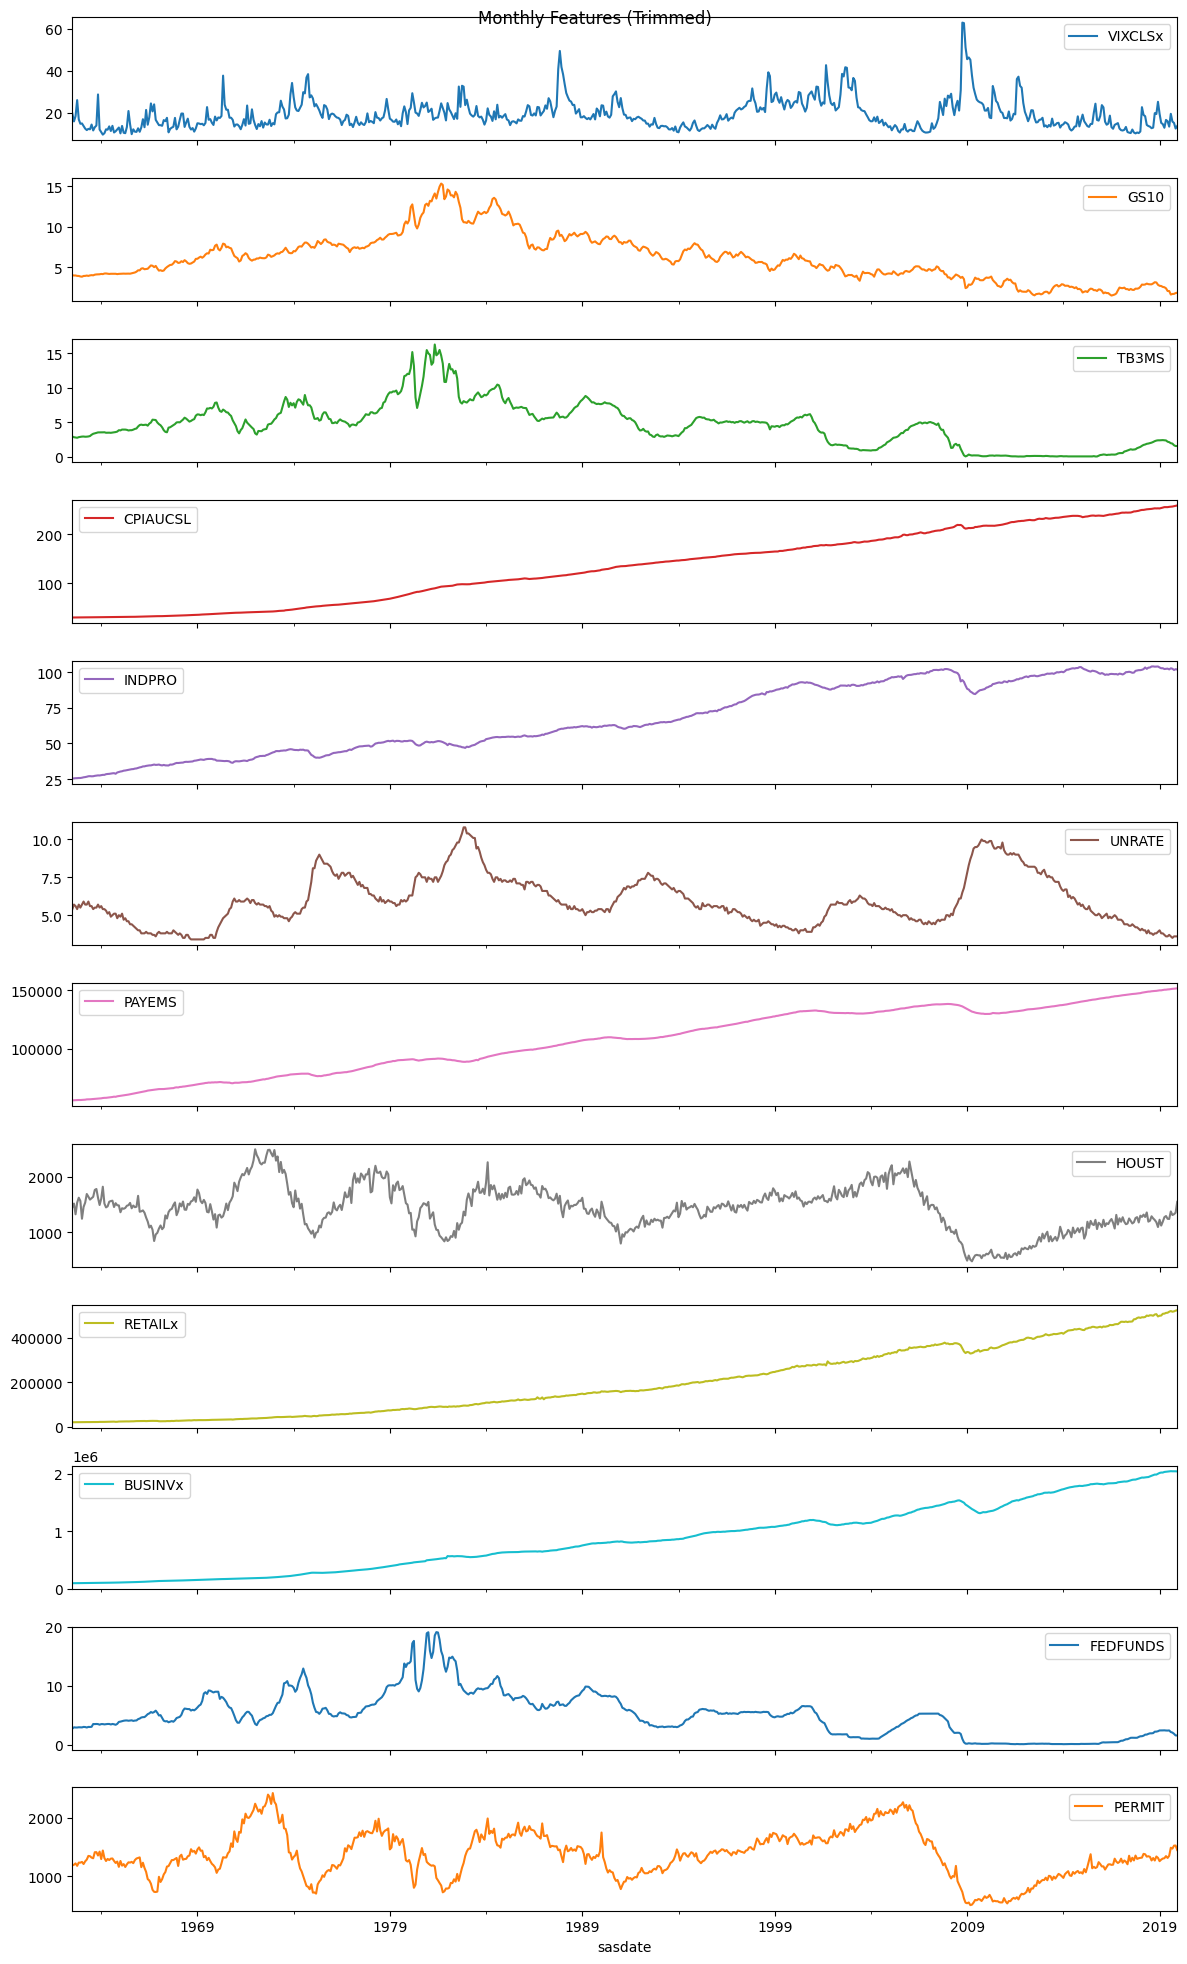

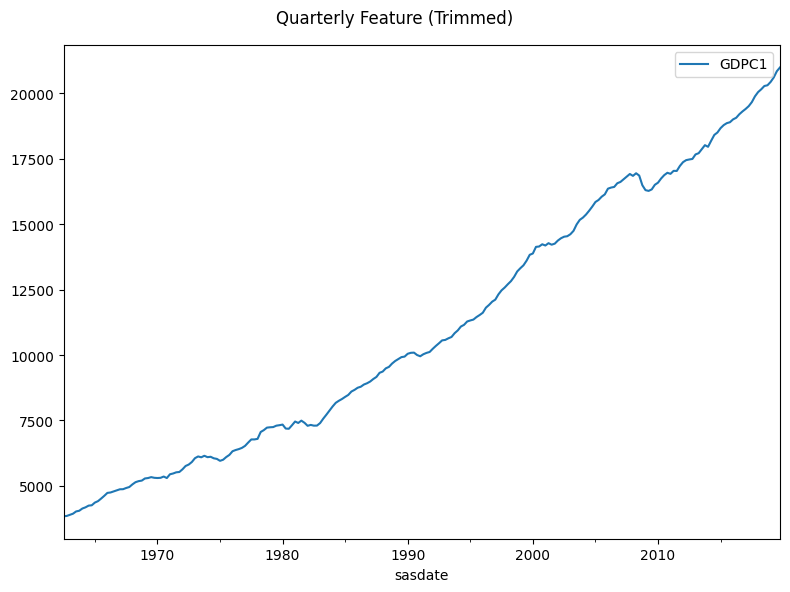

In [5]:
# --- Plot each feature in the monthly dataset ---
monthly_trimmed.plot(subplots=True, figsize=(12, 20), title="Monthly Features (Trimmed)")
plt.tight_layout()
plt.show()

# --- Plot each feature in the quarterly dataset ---
quarterly_trimmed.plot(subplots=True, figsize=(8, 6), title="Quarterly Feature (Trimmed)")
plt.tight_layout()
plt.show()

In [6]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(df):
    results = {}
    for col in df.columns:
        series = df[col].dropna()
        adf_result = adfuller(series)
        results[col] = {
            "ADF Statistic": adf_result[0],
            "p-value": adf_result[1],
            "Stationary": adf_result[1] <= 0.05
        }
    return pd.DataFrame(results).T.sort_values("p-value")

stationarity_monthly = check_stationarity(monthly_trimmed)
stationarity_quarterly = check_stationarity(quarterly_trimmed)
display(stationarity_monthly)
display(stationarity_quarterly)

,ADF Statistic,p-value,Stationary
VIXCLSx,-4.79758,0.000055,True
HOUST,-3.843392,0.002493,True
PERMIT,-3.819338,0.002716,True
UNRATE,-2.937394,0.041169,True
FEDFUNDS,-2.615066,0.089923,False
TB3MS,-1.972465,0.298775,False
GS10,-1.067487,0.727862,False
INDPRO,-1.052853,0.733503,False
PAYEMS,-0.947289,0.772001,False
CPIAUCSL,1.011154,0.994382,False


,ADF Statistic,p-value,Stationary
GDPC1,2.083127,0.998772,False


In [7]:
# Apply differencing to non-stationary monthly features
non_stationary_monthly = stationarity_monthly[stationarity_monthly["Stationary"] == False].index.tolist()
monthly_stationary = monthly_trimmed.copy()
monthly_stationary[non_stationary_monthly] = monthly_stationary[non_stationary_monthly].diff()
monthly_stationary = monthly_stationary.iloc[3:]  # Drop the first three months (1 quarter) after differencing

# Apply differencing to non-stationary quarterly features
non_stationary_quarterly = stationarity_quarterly[stationarity_quarterly["Stationary"] == False].index.tolist()
quarterly_stationary = quarterly_trimmed.copy()
quarterly_stationary[non_stationary_quarterly] = quarterly_stationary[non_stationary_quarterly].diff()
quarterly_stationary = quarterly_stationary.iloc[1:]  # Drop the first quarter (three months) after differencing

# --- Step 3: Re-check stationarity ---
stationarity_monthly_after = check_stationarity(monthly_stationary)
stationarity_quarterly_after = check_stationarity(quarterly_stationary)

# Display resultsprint
print("Monthly Stationarity After Transformation")
display(stationarity_monthly_after)

print("\nQuarterly Stationarity After Transformation")
display(stationarity_quarterly_after)

assert stationarity_monthly_after["Stationary"].all(), "Not all monthly features are stationary after differencing.\n" + str(stationarity_monthly_after[stationarity_monthly_after["Stationary"] == False])
assert stationarity_quarterly_after["Stationary"].all(), "Not all quarterly features are stationary after differencing.\n" + str(stationarity_quarterly_after[stationarity_quarterly_after["Stationary"] == False])



Monthly Stationarity After Transformation


,ADF Statistic,p-value,Stationary
INDPRO,-7.653876,0.0,True
GS10,-7.226574,0.0,True
BUSINVx,-6.282404,0.0,True
TB3MS,-5.870592,0.0,True
RETAILx,-5.846993,0.0,True
FEDFUNDS,-5.334191,0.000005,True
PAYEMS,-5.053824,0.000017,True
VIXCLSx,-4.816846,0.00005,True
CPIAUCSL,-4.572675,0.000145,True
HOUST,-3.843972,0.002488,True



Quarterly Stationarity After Transformation


,ADF Statistic,p-value,Stationary
GDPC1,-6.844325,0.0,True


In [8]:
# Step 1: Get list of stationary features (those that were not differenced)
stationary_monthly_cols = stationarity_monthly[stationarity_monthly["Stationary"] == True].index.tolist()
stationary_quarterly_cols = stationarity_quarterly[stationarity_quarterly["Stationary"] == True].index.tolist()

# Step 2: Create the final monthly dataset
# - Use differenced versions for non-stationary columns
# - Use original trimmed values for stationary columns
final_monthly_stationary = pd.concat([
    monthly_stationary[non_stationary_monthly],  # differenced
    monthly_trimmed[stationary_monthly_cols].loc[monthly_stationary.index]  # original
], axis=1).sort_index(axis=1)

# Step 3: Final quarterly dataset with only GDPC1 (already differenced if needed)
final_quarterly_stationary = quarterly_stationary[["GDPC1"]]

# Output dataset shapes and preview
final_monthly_shape = final_monthly_stationary.shape
final_quarterly_shape = final_quarterly_stationary.shape
final_monthly_stationary.head(), final_quarterly_stationary.head(), final_monthly_shape, final_quarterly_shape


(              BUSINVx  CPIAUCSL  FEDFUNDS  GS10  HOUST  INDPRO  PAYEMS  \
 sasdate                                                                  
 1962-10-01  506.57070     -0.04      0.00 -0.05   1533  0.0269    63.0   
 1962-11-01   38.96698      0.00      0.04 -0.01   1622  0.1075    15.0   
 1962-12-01  107.15918      0.00     -0.01 -0.06   1564  0.0000   -28.0   
 1963-01-01  175.35140      0.06     -0.01 -0.03   1244  0.1881    87.0   
 1963-02-01  311.73581      0.04      0.08  0.09   1456  0.2958   115.0   
 
             PERMIT    RETAILx  TB3MS  UNRATE  VIXCLSx  
 sasdate                                                
 1962-10-01  1181.0  322.54596  -0.04     5.4  25.9671  
 1962-11-01  1236.0  108.89816   0.09     5.7  16.7658  
 1962-12-01  1236.0   -4.14850   0.04     5.5  14.6778  
 1963-01-01  1248.0   88.15565   0.04     5.7  14.8357  
 1963-02-01  1212.0 -158.68017   0.01     5.9  13.5542  ,
              GDPC1
 sasdate           
 1962-12-01  12.645
 1963-03-01  

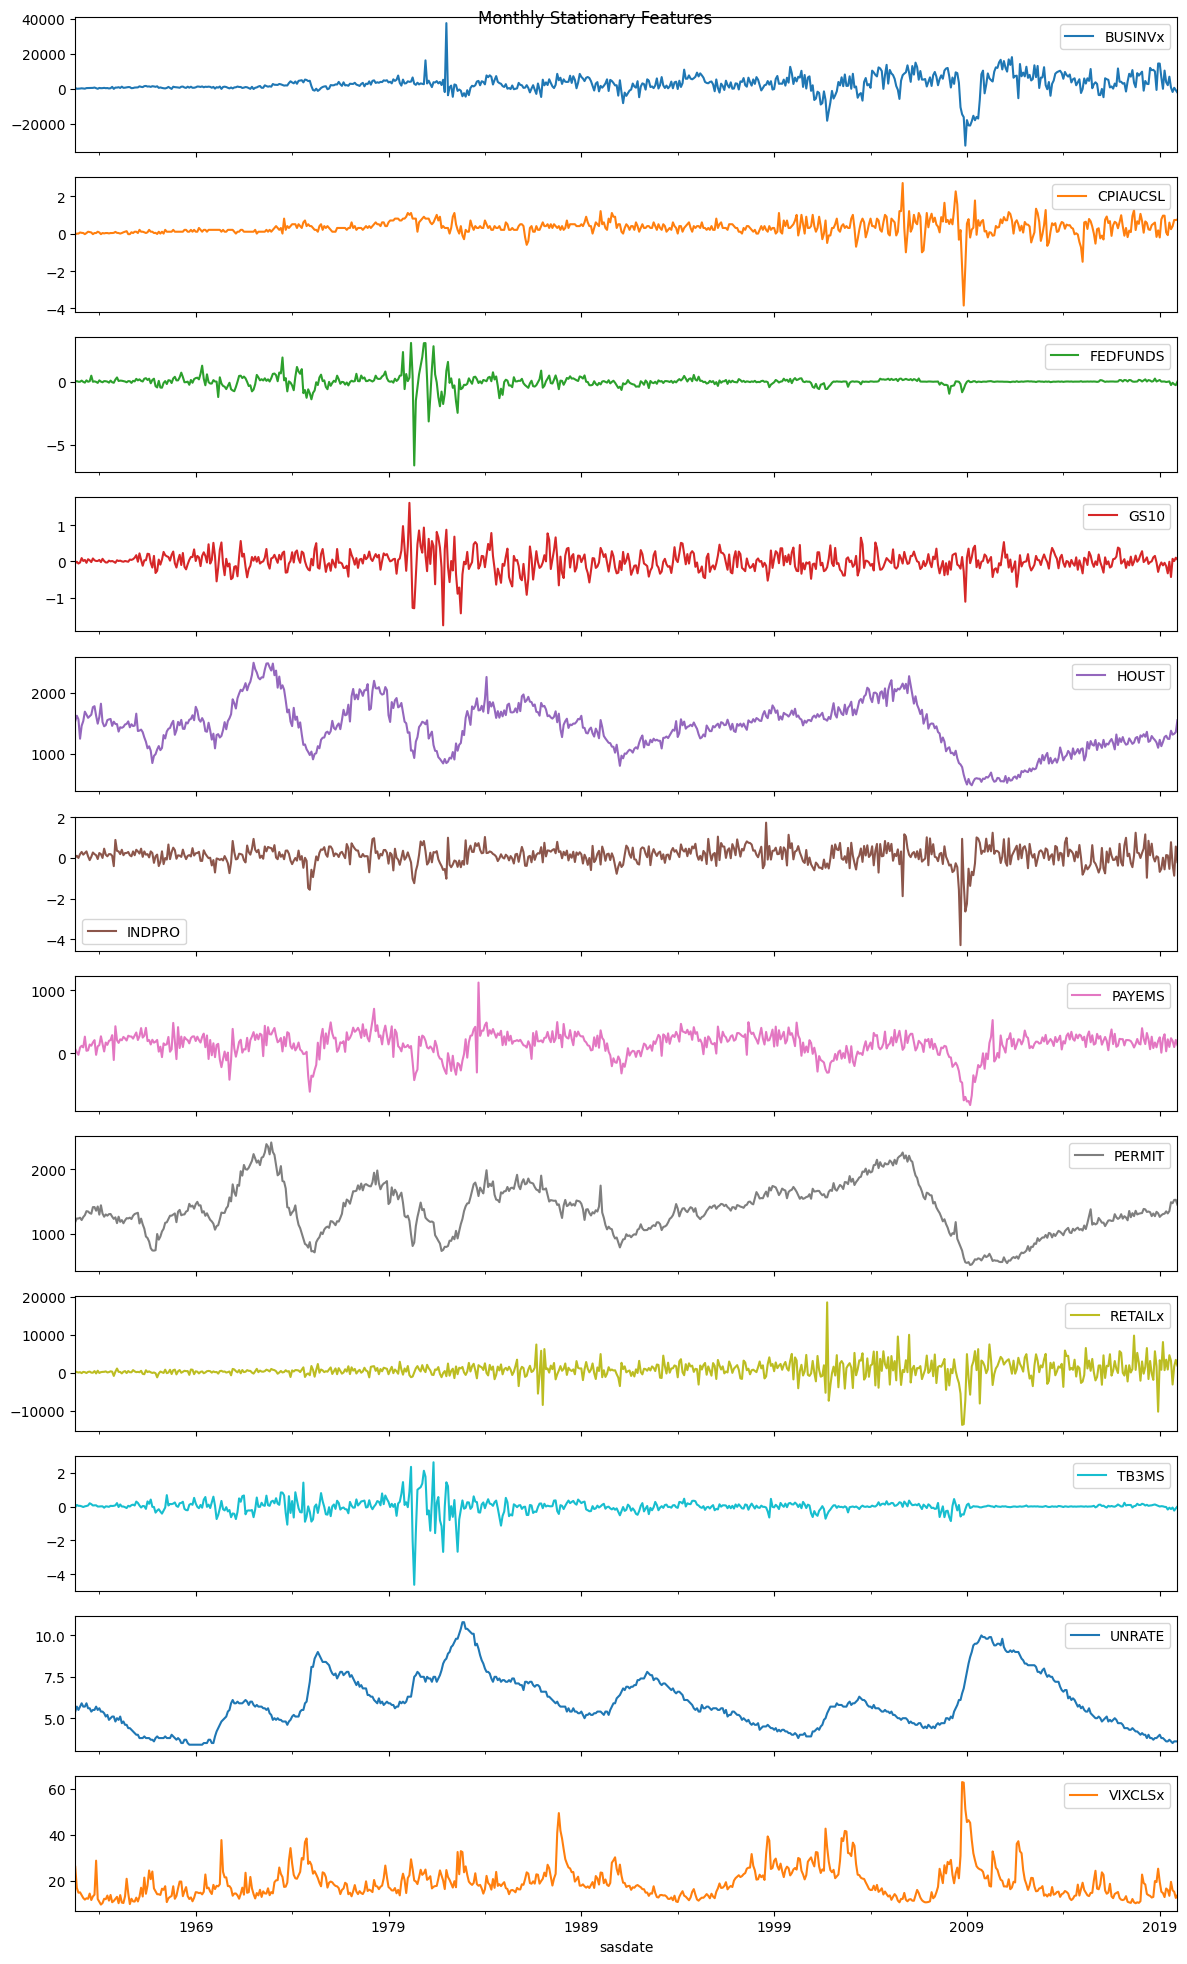

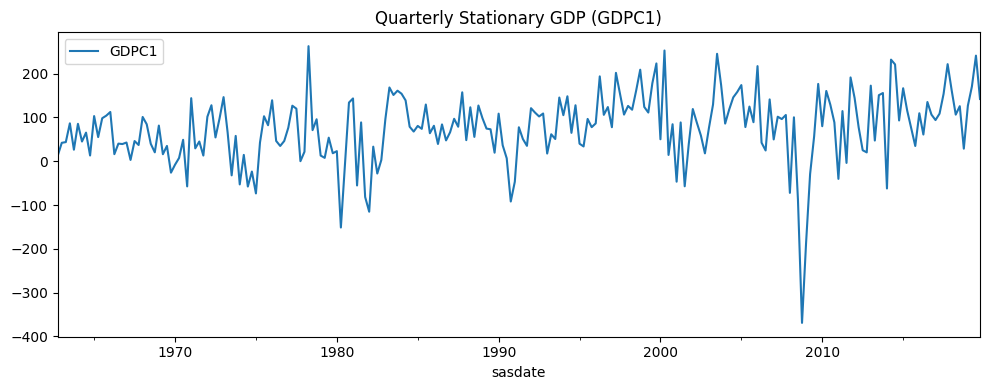

In [9]:
# Plotting
final_monthly_stationary.plot(subplots=True, figsize=(12, 20), title="Monthly Stationary Features")
plt.tight_layout()
plt.show()

final_quarterly_stationary.plot(figsize=(10, 4), title="Quarterly Stationary GDP (GDPC1)")
plt.tight_layout()
plt.show()

Model 1 preprocessing: repeating GDP values 

In [10]:
# Step 1: Repeat each quarterly observation 3 times
quarterly_repeated_values = final_quarterly_stationary.loc[final_quarterly_stationary.index.repeat(3)].reset_index(drop=True)

# Step 2: Use the last 747 months (to match the repeated quarterly series)
aligned_monthly = final_monthly_stationary# .iloc[-len(quarterly_repeated_values):].copy()

if len(quarterly_repeated_values) != len(aligned_monthly):
    raise Exception("len(quarterly_repeated_values) != len(aligned_monthly)", len(quarterly_repeated_values), '!=', len(aligned_monthly))
else:
    print("quarterly and monthly have same len:", len(quarterly_repeated_values), '==', len(aligned_monthly))

# Step 3: Assign matching monthly index to repeated quarterly values
quarterly_repeated_values.index = aligned_monthly.index

# Final aligned series
aligned_quarterly = quarterly_repeated_values.copy()

# Confirm shapes
print(f"{aligned_monthly.shape=}"), print(F"{aligned_quarterly.shape=}")

# Output sample
print("aligned_monthly:", aligned_monthly, sep="\n")
print("aligned_quarterly:", aligned_quarterly, sep="\n")

quarterly and monthly have same len: 687 == 687
aligned_monthly.shape=(687, 12)
aligned_quarterly.shape=(687, 1)
aligned_monthly:
               BUSINVx  CPIAUCSL  FEDFUNDS  GS10  HOUST  INDPRO  PAYEMS  \
sasdate                                                                   
1962-10-01   506.57070    -0.040      0.00 -0.05   1533  0.0269    63.0   
1962-11-01    38.96698     0.000      0.04 -0.01   1622  0.1075    15.0   
1962-12-01   107.15918     0.000     -0.01 -0.06   1564  0.0000   -28.0   
1963-01-01   175.35140     0.060     -0.01 -0.03   1244  0.1881    87.0   
1963-02-01   311.73581     0.040      0.08  0.09   1456  0.2958   115.0   
...                ...       ...       ...   ...    ...     ...     ...   
2019-08-01   719.00000     0.234     -0.27 -0.43   1375  0.7757   235.0   
2019-09-01 -1772.00000     0.394     -0.09  0.07   1311 -0.3213   194.0   
2019-10-01   607.00000     0.725     -0.21  0.01   1325 -0.8723    95.0   
2019-11-01  -790.00000     0.724     -0.28  0

Monthly: (480, 12) (103, 12) (104, 12)
Quarterly: (480, 1) (103, 1) (104, 1)
               BUSINVx  CPIAUCSL  FEDFUNDS  GS10  HOUST  INDPRO  PAYEMS  \
sasdate                                                                   
1962-10-01   506.57070     -0.04      0.00 -0.05   1533  0.0269    63.0   
1962-11-01    38.96698      0.00      0.04 -0.01   1622  0.1075    15.0   
1962-12-01   107.15918      0.00     -0.01 -0.06   1564  0.0000   -28.0   
1963-01-01   175.35140      0.06     -0.01 -0.03   1244  0.1881    87.0   
1963-02-01   311.73581      0.04      0.08  0.09   1456  0.2958   115.0   
...                ...       ...       ...   ...    ...     ...     ...   
2002-05-01  3919.00000      0.20      0.00 -0.05   1764  0.3841    17.0   
2002-06-01  1949.00000      0.10      0.00 -0.23   1717  0.7388    41.0   
2002-07-01  6584.00000      0.40     -0.02 -0.28   1655 -0.0300   -90.0   
2002-08-01  1519.00000      0.50      0.01 -0.39   1633 -0.0931    -1.0   
2002-09-01  8181.00000 

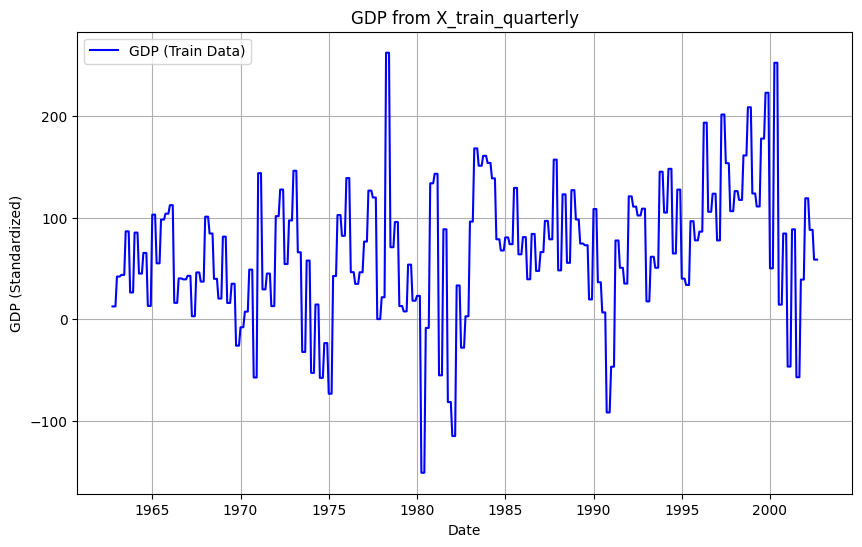

In [11]:
# Step 3: Split proportions
train_size = 0.7
val_size = 0.15
test_size = 0.15

# Step 4: Split indices
n = len(aligned_monthly)
train_end = int(n * train_size)
val_end = train_end + int(n * val_size)

# Step 5: Create splits
X_train_monthly = aligned_monthly.iloc[:train_end]
X_val_monthly = aligned_monthly.iloc[train_end:val_end]
X_test_monthly = aligned_monthly.iloc[val_end:]

X_raw_train_monthly = monthly_trimmed.iloc[:train_end]
X_raw_val_monthly = monthly_trimmed.iloc[train_end:val_end]
X_raw_test_monthly = monthly_trimmed.iloc[val_end:]

X_train_quarterly = aligned_quarterly.iloc[:train_end]
X_val_quarterly = aligned_quarterly.iloc[train_end:val_end]
X_test_quarterly = aligned_quarterly.iloc[val_end:]

X_raw_train_quarterly = quarterly_trimmed.iloc[:train_end // 3]
X_raw_val_quarterly = quarterly_trimmed.iloc[train_end // 3:val_end // 3]
X_raw_test_quarterly = quarterly_trimmed.iloc[val_end // 3:]

# Confirm shapes
print("Monthly:", X_train_monthly.shape, X_val_monthly.shape, X_test_monthly.shape)
print("Quarterly:", X_train_quarterly.shape, X_val_quarterly.shape, X_test_quarterly.shape)

print(X_train_monthly)
print(X_train_quarterly)

# Plot GDP from X_train_quarterly
plt.figure(figsize=(10, 6))
plt.plot(X_train_quarterly.index, X_train_quarterly["GDPC1"], label="GDP (Train Data)", color="blue")
plt.title("GDP from X_train_quarterly")
plt.xlabel("Date")
plt.ylabel("GDP (Standardized)")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# Initialize the scaler
scaler_monthly = StandardScaler()
scaler_quarterly = StandardScaler()

# Fit the scaler on the training data and transform training, validation, and test sets
X_train_monthly_scaled = pd.DataFrame(scaler_monthly.fit_transform(X_train_monthly), 
                                      index=X_train_monthly.index, 
                                      columns=X_train_monthly.columns)

X_val_monthly_scaled = pd.DataFrame(scaler_monthly.transform(X_val_monthly), 
                                    index=X_val_monthly.index, 
                                    columns=X_val_monthly.columns)

X_test_monthly_scaled = pd.DataFrame(scaler_monthly.transform(X_test_monthly), 
                                     index=X_test_monthly.index, 
                                     columns=X_test_monthly.columns)

X_train_quarterly_scaled = pd.DataFrame(scaler_quarterly.fit_transform(X_train_quarterly), 
                                        index=X_train_quarterly.index, 
                                        columns=X_train_quarterly.columns)

X_val_quarterly_scaled = pd.DataFrame(scaler_quarterly.transform(X_val_quarterly), 
                                      index=X_val_quarterly.index, 
                                      columns=X_val_quarterly.columns)

X_test_quarterly_scaled = pd.DataFrame(scaler_quarterly.transform(X_test_quarterly), 
                                       index=X_test_quarterly.index, 
                                       columns=X_test_quarterly.columns)

# Confirm shapes
print("Monthly Scaled:", X_train_monthly_scaled.shape, X_val_monthly_scaled.shape, X_test_monthly_scaled.shape)
print("Quarterly Scaled:", X_train_quarterly_scaled.shape, X_val_quarterly_scaled.shape, X_test_quarterly_scaled.shape)

Monthly Scaled: (480, 12) (103, 12) (104, 12)
Quarterly Scaled: (480, 1) (103, 1) (104, 1)


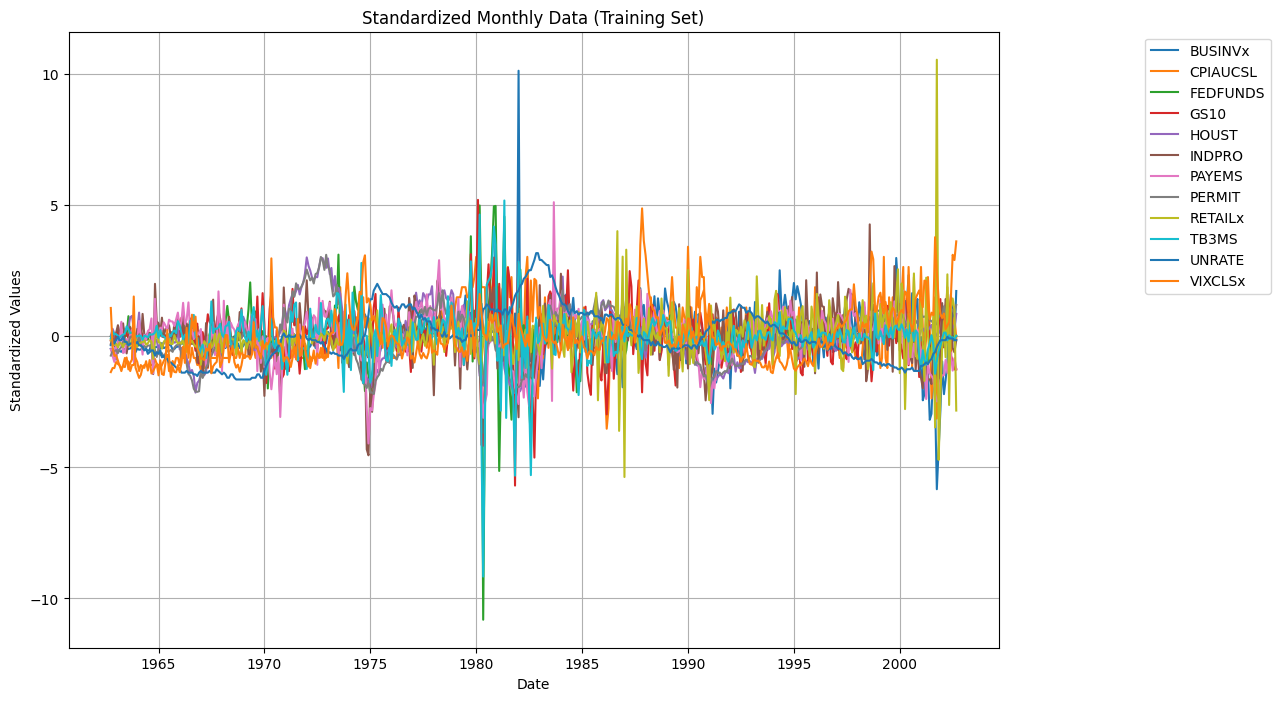

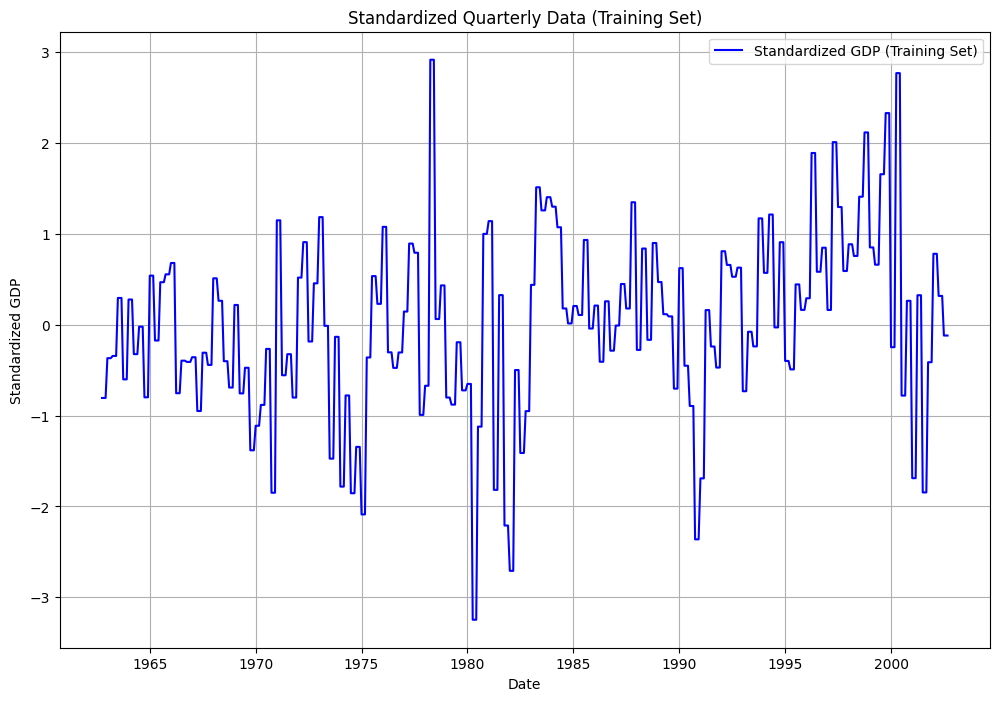

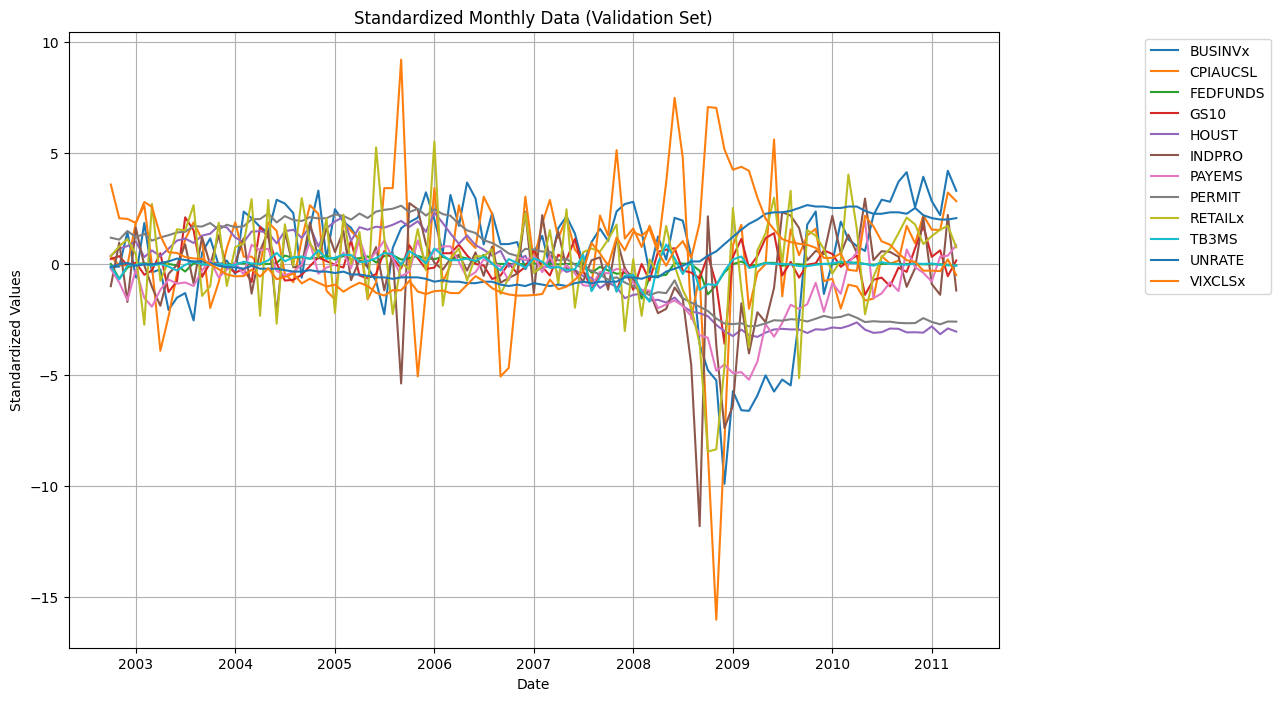

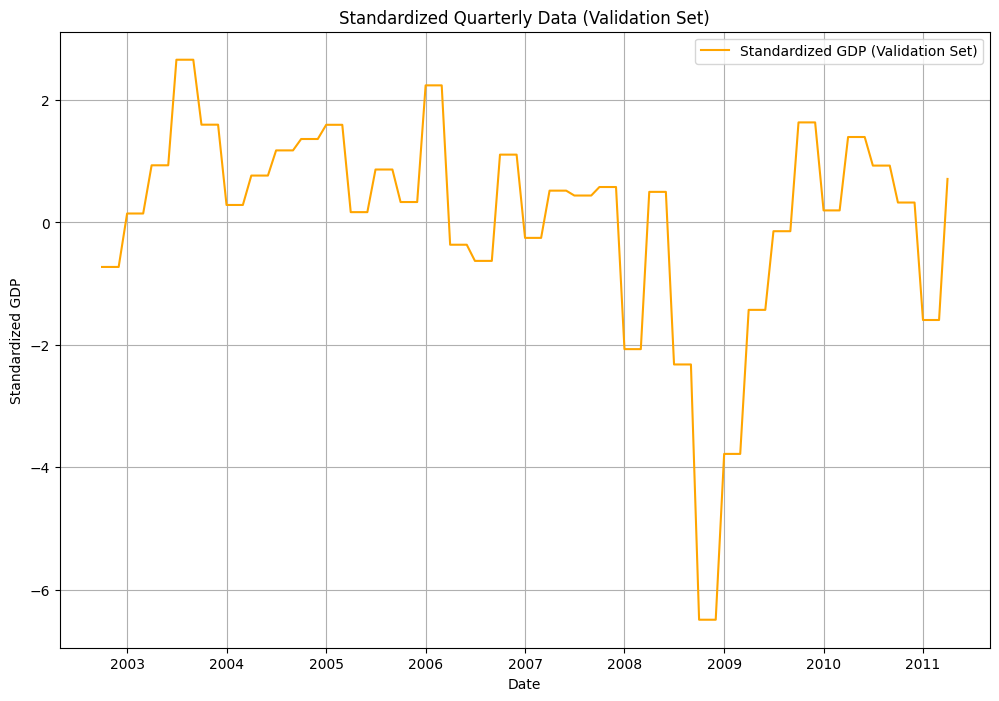

In [13]:
# Plot standardized monthly data
plt.figure(figsize=(12, 8))
for column in X_train_monthly_scaled.columns:
    plt.plot(X_train_monthly_scaled.index, X_train_monthly_scaled[column], label=column)
plt.title("Standardized Monthly Data (Training Set)")
plt.xlabel("Date")
plt.ylabel("Standardized Values")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
plt.grid(True)
plt.show()

# Plot standardized quarterly data
plt.figure(figsize=(12, 8))
plt.plot(X_train_quarterly_scaled.index, X_train_quarterly_scaled["GDPC1"], label="Standardized GDP (Training Set)", color="blue")
plt.title("Standardized Quarterly Data (Training Set)")
plt.xlabel("Date")
plt.ylabel("Standardized GDP")
plt.legend()
plt.grid(True)
plt.show()

# Plot standardized monthly validation data
plt.figure(figsize=(12, 8))
for column in X_val_monthly_scaled.columns:
    plt.plot(X_val_monthly_scaled.index, X_val_monthly_scaled[column], label=column)
plt.title("Standardized Monthly Data (Validation Set)")
plt.xlabel("Date")
plt.ylabel("Standardized Values")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
plt.grid(True)
plt.show()

# Plot standardized quarterly validation data
plt.figure(figsize=(12, 8))
plt.plot(X_val_quarterly_scaled.index, X_val_quarterly_scaled["GDPC1"], label="Standardized GDP (Validation Set)", color="orange")
plt.title("Standardized Quarterly Data (Validation Set)")
plt.xlabel("Date")
plt.ylabel("Standardized GDP")
plt.legend()
plt.grid(True)
plt.show()

Preprocess into datapoints with 12 months of historical data (X) the GDP that is to be predicted (Y)

In [ ]:
# Step 1: Initialize empty lists for validation x and y
sequence_length = 12 # Number of months (so one year)

# Step 1: Initialize empty lists for x and y
x_data_monthly = []
x_data_quarterly = []
y_data = []

previous_gdp_train = []

for i in range(len(X_train_monthly) - sequence_length - 2):  # -2 to account for the next quarter
    x_seq_monthly = X_train_monthly_scaled.iloc[i:i + sequence_length].values
    x_seq_quarterly = X_train_quarterly_scaled.iloc[i:i + sequence_length].values
    y = X_train_quarterly_scaled.iloc[i + sequence_length + 2]

    previous_gdp_train.append(X_raw_train_quarterly.iloc[(i + sequence_length + 2) // 3][["GDPC1"]])
    x_data_monthly.append(x_seq_monthly)
    x_data_quarterly.append(x_seq_quarterly)
    y_data.append(y[["GDPC1"]])

# Step 3: Convert lists to numpy arrays
previous_gdp_train = np.array(previous_gdp_train)
x_train_md = np.array(x_data_monthly)
x_train_qd = np.array(x_data_quarterly)
y_train = np.array(y_data)

# Output shapes
print("previous_gdp_train shape:", previous_gdp_train.shape)
print("x_train_md shape:", x_train_md.shape)
print("x_train_qd shape:", x_train_qd.shape)
print("y_train shape:", y_train.shape)

previous_gdp_train shape: (465, 1)
x_train_md shape: (465, 12, 12)
x_train_qd shape: (465, 12, 1)
y_train shape: (465, 1)


In [46]:
# Step 1: Initialize empty lists for validation x and y
sequence_length = 12 # Number of months (so one year)

# Step 1: Initialize empty lists for x and y
x_data_monthly_val = []
x_data_quarterly_val = []
y_data_val = []
previous_gdp_val = []

for i in range(len(X_val_monthly) - sequence_length - 3):  # -3 to account for the next quarter
    x_seq_monthly_val = X_val_monthly_scaled.iloc[i:i + sequence_length].values
    x_seq_quarterly_val = X_val_quarterly_scaled.iloc[i:i + sequence_length].values
    y_val = X_val_quarterly_scaled.iloc[i + sequence_length + 2]
    
    previous_gdp_val.append(X_raw_val_quarterly.iloc[(i + sequence_length + 2) // 3][["GDPC1"]])
    x_data_monthly_val.append(x_seq_monthly_val)
    x_data_quarterly_val.append(x_seq_quarterly_val)
    y_data_val.append(y_val[["GDPC1"]])

# Step 3: Convert lists to numpy arrays
previous_gdp_val = np.array(previous_gdp_val)
x_val_md = np.array(x_data_monthly_val)
x_val_qd = np.array(x_data_quarterly_val)
y_val = np.array(y_data_val)

# Output shapes
print("previous_gdp_val shape:", previous_gdp_val.shape)
print("x_val_md shape:", x_val_md.shape)
print("x_val_qd shape:", x_val_qd.shape)
print("y_val shape:", y_val.shape)

previous_gdp_val shape: (88, 1)
x_val_md shape: (88, 12, 12)
x_val_qd shape: (88, 12, 1)
y_val shape: (88, 1)


In [16]:
# Step 1: Define inputs
monthly_input = Input(shape=(sequence_length, x_train_md.shape[2]), name="monthly_input")
quarterly_input = Input(shape=(sequence_length, x_train_qd.shape[2]), name="quarterly_input")

# Step 2: Concatenate monthly + quarterly input along feature axis
combined_input = Concatenate(axis=-1)([monthly_input, quarterly_input])

# Step 3: LSTM model
x = LSTM(64, return_sequences=False)(combined_input)[:, None]
output = TimeDistributed(Dense(1))(x)[..., 0]

# Step 4: Define model
model = Model(inputs=[monthly_input, quarterly_input], outputs=output)
model.compile(optimizer="adam", loss="mse")

# Summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ monthly_input       │ (None, 12, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quarterly_input     │ (None, 12, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 12, 13)    │          0 │ monthly_input[0]… │
│ (Concatenate)       │                   │            │ quarterly_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     19,968 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 1, 64)     │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 1, 1)      │         65 │ get_item[0][0]    │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 1)         │          0 │ time_distributed… │
│ (GetItem)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 20,033 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

start taining
Initial validation Loss: 2.7465784549713135
Initial train Loss: 0.9730749130249023
Epoch 1/15
 1/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - loss: 0.5245
Epoch 1: val_loss improved from inf to 2.06101, saving model to results/best_model1_nonmmixed_stationarization.weights.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.7877 - val_loss: 2.0610
Epoch 2/15
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.6372
Epoch 2: val_loss improved from 2.06101 to 1.98125, saving model to results/best_model1_nonmmixed_stationarization.weights.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7108 - val_loss: 1.9813
Epoch 3/15
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.4768
Epoch 3: val_loss improved from 1.98125 to 1.96891, saving model to results/best_model1_nonmmixed_stationarization.weights.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6252 - val_loss: 1.9689
Epoch 4/15
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.6580
Epoch 4: val_loss did not improve from 1.9689

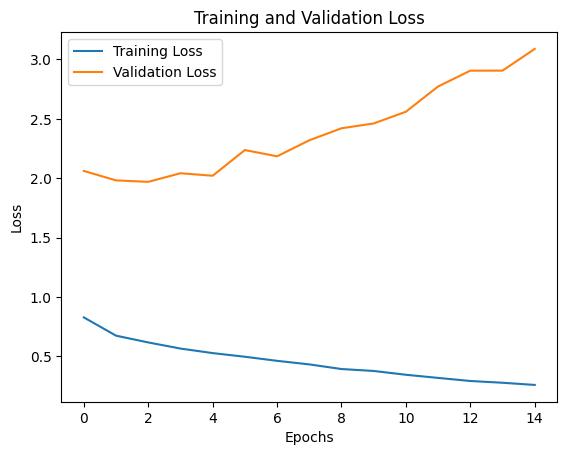

Validation Loss: 3.0890350341796875
Train Loss: 0.23300805687904358


In [17]:
# Step 1: Train the model
print("start taining")

# Step 3: Evaluate the model on validation data
initial_val_loss = model.evaluate([x_val_md, x_val_qd], y_val, verbose=0)
print(f"Initial validation Loss: {initial_val_loss}")
initial_train_loss = model.evaluate([x_train_md, x_train_qd], y_train, verbose=0)
print(f"Initial train Loss: {initial_train_loss}")

checkpoint_filepath = 'results/best_model1_nonmmixed_stationarization.weights.h5'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)


history = model.fit(
    # [x_train_md[:400], x_train_qd[:400]],  # Inputs: monthly and quarterly sequences
    # y_train[:400],                  # Target: next quarter GDP
    # validation_data=([x_train_md[400:], x_train_qd[400:]], y_train[400:]),  # Validation data
    [x_train_md, x_train_qd],  # Inputs: monthly and quarterly sequences
    y_train,                  # Target: next quarter GDP
    validation_data=([x_val_md, x_val_qd], y_val),  # Validation data
    epochs=15,               # Number of epochs
    batch_size=32,           # Batch size
    verbose=1,                # Verbosity level'
    shuffle=True,           # Shuffle the data before each epoch
    callbacks=[model_checkpoint_callback]  # Save the best model weights
)

# Step 2: Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Step 3: Evaluate the model on validation data
val_loss = model.evaluate([x_val_md, x_val_qd], y_val, verbose=0)
print(f"Validation Loss: {val_loss}")
train_loss = model.evaluate([x_train_md, x_train_qd], y_train, verbose=0)
print(f"Train Loss: {train_loss}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
initial_gdp=np.float64(17444.525)
RMSE (real): 94.19071929185405
MAE (real): 67.26777449032396
GDP range: 15162.76 to 16960.864


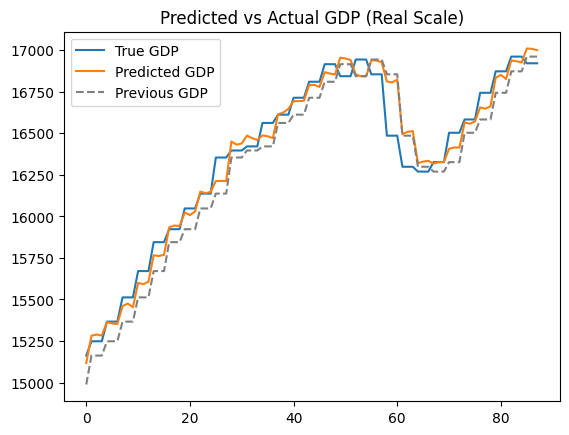

In [38]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error# Load the best model weights after training
model.load_weights(checkpoint_filepath)
y_pred = model.predict([x_val_md, x_val_qd])

# print(X_train_quarterly)

initial_gdp = quarterly_trimmed.iloc[(val_end + sequence_length + 2) // 3]["GDPC1"]
print(f"{initial_gdp=}")
y_pred_inv = scaler_quarterly.inverse_transform(y_pred)
# Invert the differencing to restore the original scale
y_pred_inv = previous_gdp_val + y_pred_inv

y_true_inv = scaler_quarterly.inverse_transform(y_val)
# Invert the differencing to restore the original scale
y_true_inv = previous_gdp_val + y_true_inv


rmse_real = root_mean_squared_error(y_true_inv, y_pred_inv)
mae_real = mean_absolute_error(y_true_inv, y_pred_inv)
print("RMSE (real):", rmse_real)	
print("MAE (real):", mae_real)

# Plot
print("GDP range:", y_true_inv.min(), "to", y_true_inv.max())

plt.plot(y_true_inv, label="True GDP")
plt.plot(y_pred_inv, label="Predicted GDP")
plt.plot(previous_gdp_val, label="Previous GDP", linestyle='--', color='gray')
plt.title("Predicted vs Actual GDP (Real Scale)")
plt.legend()
plt.show()

# plt.plot((y_true_inv - previous_gdp_val)[:-3], label="Y_val")
# plt.plot(previous_gdp_val[3:] - previous_gdp_val[:-3], label="True GDP Growth", linestyle='--', color='gray')

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
initial_gdp=np.float64(3838.776)
RMSE (real): 50.720836821810444
MAE (real): 39.76789348343617
GDP range: 4050.147 to 14519.633


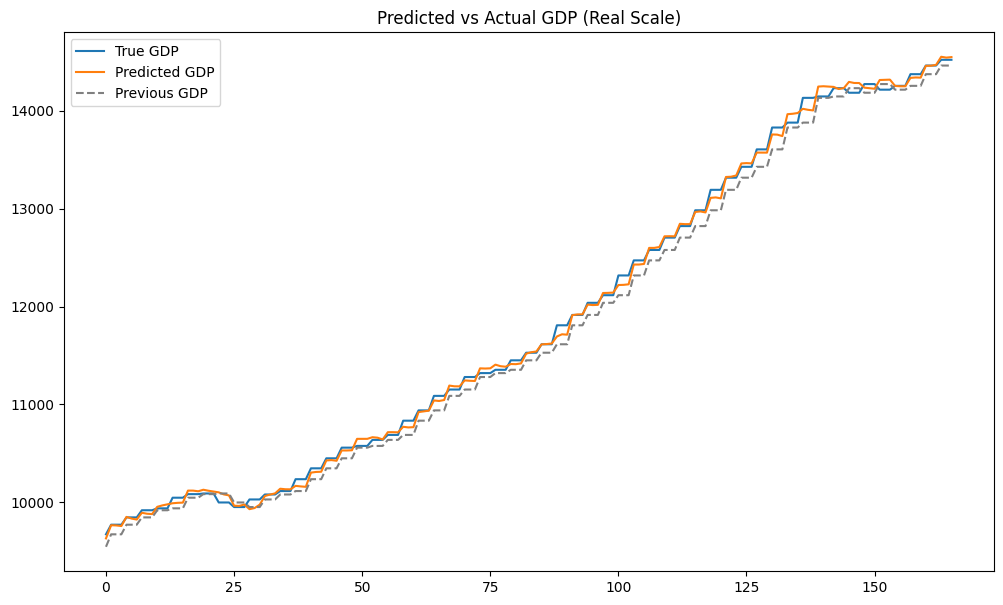

In [41]:
model.load_weights(checkpoint_filepath)
y_pred = model.predict([x_train_md, x_train_qd])

initial_gdp = quarterly_trimmed.iloc[0]["GDPC1"]
print(f"{initial_gdp=}")
y_pred_inv = scaler_quarterly.inverse_transform(y_pred)
y_pred_inv += previous_gdp_train
y_true_inv = scaler_quarterly.inverse_transform(y_train)
y_true_inv += previous_gdp_train

rmse_real = root_mean_squared_error(y_true_inv, y_pred_inv)
mae_real = mean_absolute_error(y_true_inv, y_pred_inv)
print("RMSE (real):", rmse_real)	
print("MAE (real):", mae_real)

# Plot
print("GDP range:", y_true_inv.min(), "to", y_true_inv.max())

plt.figure(figsize=(12, 7))
plt.plot(y_true_inv[300:], label="True GDP")
plt.plot(y_pred_inv[300:], label="Predicted GDP")
plt.plot(previous_gdp_train[300:], label="Previous GDP", linestyle='--', color='gray')
plt.title("Predicted vs Actual GDP (Real Scale)")
plt.legend()
plt.show()

y_val:
[[ 1.59731872]
 [ 0.28549981]
 [ 0.28549981]
 [ 0.28549981]
 [ 0.76593497]
 [ 0.76593497]
 [ 0.76593497]
 [ 1.1770832 ]
 [ 1.1770832 ]
 [ 1.1770832 ]
 [ 1.3631792 ]
 [ 1.3631792 ]
 [ 1.3631792 ]
 [ 1.59536718]
 [ 1.59536718]
 [ 1.59536718]
 [ 0.16833322]
 [ 0.16833322]
 [ 0.16833322]
 [ 0.86477799]
 [ 0.86477799]
 [ 0.86477799]
 [ 0.33357312]
 [ 0.33357312]
 [ 0.33357312]
 [ 2.2397313 ]
 [ 2.2397313 ]
 [ 2.2397313 ]
 [-0.36407833]
 [-0.36407833]
 [-0.36407833]
 [-0.62819105]
 [-0.62819105]
 [-0.62819105]
 [ 1.10794522]
 [ 1.10794522]
 [ 1.10794522]
 [-0.25223005]
 [-0.25223005]
 [-0.25223005]
 [ 0.51944566]
 [ 0.51944566]
 [ 0.51944566]
 [ 0.43973067]
 [ 0.43973067]
 [ 0.43973067]
 [ 0.57873658]
 [ 0.57873658]
 [ 0.57873658]
 [-2.06986898]
 [-2.06986898]
 [-2.06986898]
 [ 0.49954299]
 [ 0.49954299]
 [ 0.49954299]
 [-2.32026136]
 [-2.32026136]
 [-2.32026136]
 [-6.49072165]
 [-6.49072165]
 [-6.49072165]
 [-3.78155892]
 [-3.78155892]
 [-3.78155892]
 [-1.42823105]
 [-1.42823105]
 [-

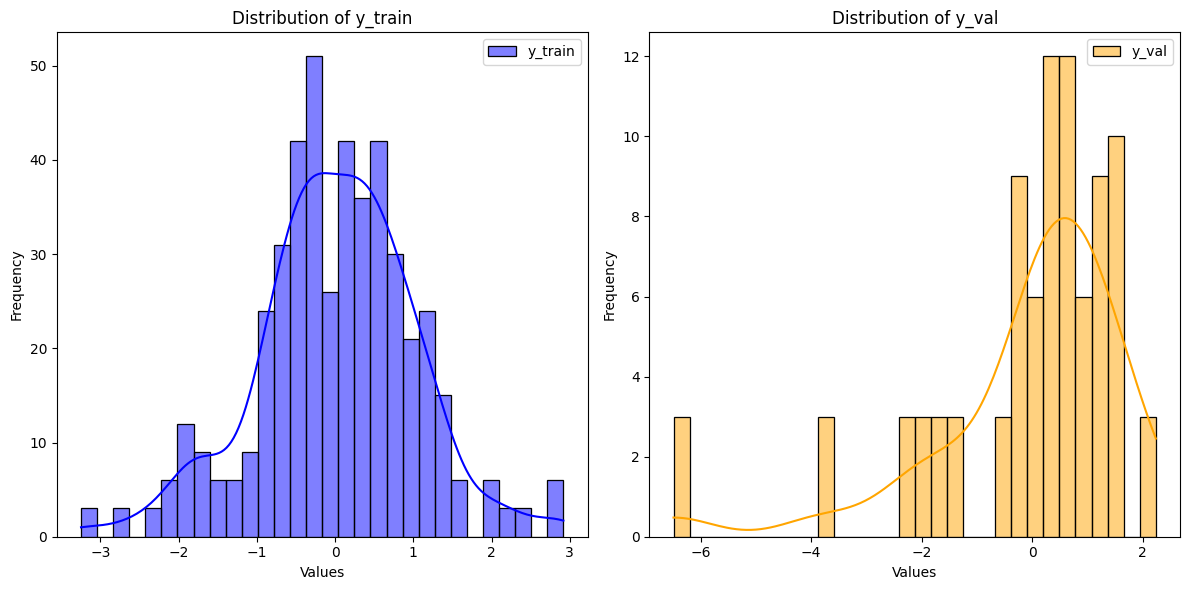

In [ ]:
print("y_val:")
print(y_val)

print("\ny_train:")
print(y_train)
# Visualize the distributions of y_train and y_val
plt.figure(figsize=(12, 6))

# Plot y_train distribution
plt.subplot(1, 2, 1)
sns.histplot(y_train.flatten(), kde=True, bins=30, color="blue", label="y_train")
plt.title("Distribution of y_train")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.legend()

# Plot y_val distribution
plt.subplot(1, 2, 2)
sns.histplot(y_val.flatten(), kde=True, bins=30, color="orange", label="y_val")
plt.title("Distribution of y_val")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()
